<h1 style="text-align:center">
    Movies
</h1>

<br>

<font color="darkblue">

<h3 style="text-align:center">
    David Carrera Pintor
</h3>
    
<h3 style="text-align:center">
    26/03/2025
</h3>
/
<hr>/

# Introducción

<br>

En este proyecto se desarrolla en Python un análisis básico de datos sobre películas de cine de IMDB.
El set de datos que vamos a usar inicialmente se encuentra en la siguiente página:

https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset

En ella puede encontrarse información más detallada, así como una descripción precisa de cada columna.


<br>

Se plantean los apartados iniciales para su resolución *sin usar la libreria pandas*. Esto se propone así para forzar a practicar con las técnicas, herramientas y conceptos básicos de Python. Más adelante, hay otros apartados propuestos para su resolución con esta librería y otras.

<br>

<font color="darkblue">
Aunque al final de este notebook detallaré la calificación que calculo honestamente, globalmente, siguiendo las puntuaciones asignadas a cada apartado, considero que he obtenido una nota de 9,9 sobre 10. Esto se debe a que he logrado desarrollar todos los programas correctamente, respetando los criterios y métodos enseñados en clases y apuntes bajo mi punto de vista. Además, en el apartado opcional, he ampliado el uso de pandas para realizar una limpieza y transformación de datos más exhaustiva, integrado Plotly para generar gráficos interactivos, e incorporado Tkinter para crear una interfaz de usuario que facilita la interacción y visualización dinámica.
</font>

<br>

# Datos de partida

(**Nota previa:** hasta el apartado específico de dataframes, se deben desarrollar las soluciones a los ejercicios propuestos sin usar la librería `pandas`, justamente para obligar a practicar con conceptos básicos de Python.)

Nuestra tabla de datos es un archivo de texto (`ds_salaries.csv`) que puede verse así con cualquier editor:

<br>

<center>
    <img src="./images/texto.png" width="100%">
</center>

La primera fila es la cabecera.
Esta fila cabecera contiene los nombres de los campos, separados por comas.
Yo la he marcado en azul para distinguirla fácilmente de las demás filas, que contienen los datos propiamente dichos,
esto es, los valores de dichos campos, consignando los datos de cada película en cada línea.

Si abrimos esta tabla con *excell* (importar datos csv con el separador `,`), vemos cada dato en una celda.

<br>

<center>
    <img src="./images/csv_1.png" width="100%">
</center>

<br>

Mostramos la hoja excell en dos imágenes por ser muy ancha.

<br>

<center>
    <img src="./images/csv_2.png" width="100%">
</center>

# Librerías y constantes globales

<br>

Pongamos todas las librerías necesarias al principio, tal como propone el estilo `pep-8`. Ej.:
<a href="https://www.python.org/dev/peps/pep-0008/">PEP 8 -- Style Guide for Python Code</a>.
    
De paso, en éste y otros lugares de Internet podrás encontrar detalles sobre estilo y presentación de código con un estilo estándar y cuidado. Examina esta página y trata de seguir esas indicaciones.

In [1]:
# Librerías:

import csv
import re
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from typing import List, Optional, Tuple, Dict
import requests
from bs4 import BeautifulSoup
import plotly.express as px
import tkinter as tk
from tkinter import filedialog, ttk, messagebox

requests.packages.urllib3.disable_warnings()




In [2]:
# Constantes globales:

MOVIES_DATA = 'data_in/movie_data.csv'
FEW_FIELDS = "algunos_campos.txt"



# Parte A. Ejercicios básicos sin usar `pandas` [2 puntos]

Esta parte inicial debe realizarse sin usar la librería `pandas`. Para practicar con esta librería, se plantean otros apartados más abajo.

### A.1. Exploración inicial básica del archivo de datos

Deseamos cargar el archivo de datos, que tiene un formato `csv`.
En este apartado, te recomiendo fuertemente usar la librería `cvs`,
que deberás importar en la primera celda del script, más arriba, no aquí.
(En los siguientes apartados, ya no mencionaré qué librerías usar
ni recordaré dónde se han de importar.)

Observa también que el test de funcionamiento te da el nombre de la función que deber definir
y algún otro identificador como es, por ejemplo, la constante `MOVIES_DATA`,
que debes definir también más arriba, en la segunda celda de este script.

Finalmente, observando el test, verás que se carga por separado la cabecera y las filas de datos.

In [3]:

def load_full_data(movies_file: str) -> tuple:
    """
    Lee los datos del archivo CSV y devuelve el encabezado y los datos.

    Parameters
    ----------
    movies_file
        La ruta al archivo con los datos.

    Returns
    -------
    tuple
        Una tupla que contiene el encabezado (lista) y los datos (lista de listas).

    Example
    --------
    >>> header, data = load_full_data("movies.csv")
    >>> print(header)
    ['color', 'director_name', 'num_critic_for_reviews', 'duration', ...]
    >>> print(data[:1])
    [['Color', 'James Cameron', '723', '178', '0', '855', 'Joel David Moore', '1000',...]]

    """
    try:
        with open(movies_file, 'r', encoding="utf-8") as file:
            reader = csv.reader(file, delimiter=',')
            header = next(reader)
            data = [row for row in reader]
        return header, data
    
    except Exception as e:
        print(f"Error reading the file: {e}")
        return None, None


In [4]:
# Test de funcionamiento

full_header, full_list_data = load_full_data(MOVIES_DATA)

print(full_header)
print()
print(full_list_data[0:5])

['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

[['Color', 'James Cameron', '723', '178', '0', '855', 'Joel David Moore', '1000', '760505847', 'Action|Adventure|Fantasy|Sci-Fi', 'CCH Pounder', 'Avatar\xa0', '886204', '4834', 'Wes Studi', '0', 'avatar|future|marine|native|paraplegic', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1', '3054', 'English', 'USA', 'PG-13', '237000000', '2009', '936', '7.9', '1.78', '33000'], ['Color', 'Gore Verbinski', '302', '169', '563', '1000', 'Orlando Bloom', '40000', '309404152', 'Action|Adventure|F

Salida esperada:

    ['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

    [['Color', 'James Cameron', '723', '178', '0', '855', 'Joel David Moore', '1000', '760505847', 'Action|Adventure|Fantasy|Sci-Fi', 'CCH Pounder', 'Avatar\xa0', '886204', '4834', 'Wes Studi', '0', 'avatar|future|marine|native|paraplegic', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1', '3054', 'English', 'USA', 'PG-13', '237000000', '2009', '936', '7.9', '1.78', '33000'], ['Color', 'Gore Verbinski', '302', '169', '563', '1000', 'Orlando Bloom', '40000', '309404152', 'Action|Adventure|Fantasy', 'Johnny Depp', "Pirates of the Caribbean: At World's End\xa0", '471220', '48350', 'Jack Davenport', '0', 'goddess|marriage ceremony|marriage proposal|pirate|singapore', 'http://www.imdb.com/title/tt0449088/?ref_=fn_tt_tt_1', '1238', 'English', 'USA', 'PG-13', '300000000', '2007', '5000', '7.1', '2.35', '0'], ['Color', 'Sam Mendes', '602', '148', '0', '161', 'Rory Kinnear', '11000', '200074175', 'Action|Adventure|Thriller', 'Christoph Waltz', 'Spectre\xa0', '275868', '11700', 'Stephanie Sigman', '1', 'bomb|espionage|sequel|spy|terrorist', 'http://www.imdb.com/title/tt2379713/?ref_=fn_tt_tt_1', '994', 'English', 'UK', 'PG-13', '245000000', '2015', '393', '6.8', '2.35', '85000'], ['Color', 'Christopher Nolan', '813', '164', '22000', '23000', 'Christian Bale', '27000', '448130642', 'Action|Thriller', 'Tom Hardy', 'The Dark Knight Rises\xa0', '1144337', '106759', 'Joseph Gordon-Levitt', '0', 'deception|imprisonment|lawlessness|police officer|terrorist plot', 'http://www.imdb.com/title/tt1345836/?ref_=fn_tt_tt_1', '2701', 'English', 'USA', 'PG-13', '250000000', '2012', '23000', '8.5', '2.35', '164000'], ['', 'Doug Walker', '', '', '131', '', 'Rob Walker', '131', '', 'Documentary', 'Doug Walker', 'Star Wars: Episode VII - The Force Awakens\xa0            ', '8', '143', '', '0', '', 'http://www.imdb.com/title/tt5289954/?ref_=fn_tt_tt_1', '', '', '', '', '', '', '12', '7.1', '', '0']]

    

Ahora, querríamos ver las posiciones de los identificadores de los campos, dados en la línea cabecera.

In [5]:

list_of_enumerated_headers = list(enumerate(full_header))

In [6]:
# Test de funcionamiento

print(list_of_enumerated_headers)

[(0, 'color'), (1, 'director_name'), (2, 'num_critic_for_reviews'), (3, 'duration'), (4, 'director_facebook_likes'), (5, 'actor_3_facebook_likes'), (6, 'actor_2_name'), (7, 'actor_1_facebook_likes'), (8, 'gross'), (9, 'genres'), (10, 'actor_1_name'), (11, 'movie_title'), (12, 'num_voted_users'), (13, 'cast_total_facebook_likes'), (14, 'actor_3_name'), (15, 'facenumber_in_poster'), (16, 'plot_keywords'), (17, 'movie_imdb_link'), (18, 'num_user_for_reviews'), (19, 'language'), (20, 'country'), (21, 'content_rating'), (22, 'budget'), (23, 'title_year'), (24, 'actor_2_facebook_likes'), (25, 'imdb_score'), (26, 'aspect_ratio'), (27, 'movie_facebook_likes')]


Salida Esperada:

    [(0, 'color'), (1, 'director_name'), (2, 'num_critic_for_reviews'), (3, 'duration'), (4, 'director_facebook_likes'), (5, 'actor_3_facebook_likes'), (6, 'actor_2_name'), (7, 'actor_1_facebook_likes'), (8, 'gross'), (9, 'genres'), (10, 'actor_1_name'), (11, 'movie_title'), (12, 'num_voted_users'), (13, 'cast_total_facebook_likes'), (14, 'actor_3_name'), (15, 'facenumber_in_poster'), (16, 'plot_keywords'), (17, 'movie_imdb_link'), (18, 'num_user_for_reviews'), (19, 'language'), (20, 'country'), (21, 'content_rating'), (22, 'budget'), (23, 'title_year'), (24, 'actor_2_facebook_likes'), (25, 'imdb_score'), (26, 'aspect_ratio'), (27, 'movie_facebook_likes')]

### A.2. Campos principales de una película

Los campos (columnas) del archivo son demasiados. No nos interesan todos ellos. Dada una lista con todos los campos, se pide extraer otra lista sólo con los campos con los que vamos a trabajar en los siguientes apartados: `movie_title`, `title_year`, `director_name`, `actor_1_name`, `language`, `country`, `color`, `budget`, `imdb_score` y `movie_imdb_link`.

In [7]:
def main_data_from_item(item: list) -> list:
    """
    Extrae los campos seleccionados de una entrada de datos de una película.

    Parameters
    ----------
    item
        Una lista que contiene el conjunto completo de atributos de la película.

    Returns
    -------
    list
        Una lista que contiene solo los campos: 
        ['movie_title', 'title_year', 'director_name', 'actor_1_name', 
        'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link'].

    Examples
    --------
    >>> full_header = ['color', 'director_name', 'num_critic_for_reviews', 'duration', 'actor_2_name', ...]
    >>> print(main_data_from_item(full_header))
    ['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link']

    """
    
    selected_fields = [
        "movie_title", "title_year", "director_name", "actor_1_name",
        "language", "country", "color", "budget", "imdb_score", "movie_imdb_link"
    ]

    selected_indices = [full_header.index(field) for field in selected_fields]

    return [item[i] for i in selected_indices]


In [8]:
# Test de funcionamiento

print(main_data_from_item(full_header))

print()

datos_avatar_2009 = main_data_from_item(full_list_data[0])
print(datos_avatar_2009)

print()

datos_star_wars_7 = main_data_from_item(full_list_data[4])
print(datos_star_wars_7)

['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link']

['Avatar\xa0', '2009', 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', '237000000', '7.9', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1']

['Star Wars: Episode VII - The Force Awakens\xa0            ', '', 'Doug Walker', 'Doug Walker', '', '', '', '', '7.1', 'http://www.imdb.com/title/tt5289954/?ref_=fn_tt_tt_1']


Salida esperada

    ['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link']

    ['Avatar\xa0', '2009', 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', '237000000', '7.9', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1']

    ['Star Wars: Episode VII - The Force Awakens\xa0            ', '', 'Doug Walker', 'Doug Walker', '', '', '', '', '7.1', 'http://www.imdb.com/title/tt5289954/?ref_=fn_tt_tt_1']

### A.3. Algunos ajustes en los campos

Observa la anomalía en el string del título de la película. También, queremos tratar algunos campos como numéricos, ya sea enteros (el año y el presupuesto) o reales (la valoración). (Algunos campos numéricos enteros están vacíos en el archivo de datos; para ellos, el valor imputado será `-1`.) Además, en las urls de las películas no necesitaremos el fragmento final, iniciado con `?ref_`.

In [9]:
def datatypes_arranged(movie_data: list) -> list:
    """
    Limpia y convierte los tipos de datos de la información de las películas.

    Parameters
    ----------
    movie_data
        Una lista que contiene la información de una película.

    Returns
    -------
    list
        Una lista con los datos de la película limpios y con los tipos correctos.

    Examples
    --------
    >>> datos_avatar_2009 = ['Avatar\xa0', '2009', 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', '237000000', '7.9', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1']
    >>> datatypes_arranged(datos_avatar_2009)
    ['Avatar', 2009, 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', 237000000, 7.9, 'http://www.imdb.com/title/tt0499549/']

    """
    if len(movie_data) < 10:
        raise ValueError("Not enoth data to process in the movie_data list")
    
    movie_data[0] = movie_data[0].strip().replace("\xa0", "")
    movie_data[1] = int(movie_data[1]) if movie_data[1].isdigit() else -1
    movie_data[7] = int(movie_data[7]) if movie_data[7].isdigit() else -1
    movie_data[8] = float(movie_data[8]) if movie_data[8] else 0.0
    movie_data[9] = re.sub(r'\?ref_.*', '', movie_data[9])

    return movie_data


In [10]:
# Test de funcionamiento

print(datatypes_arranged(datos_avatar_2009))

print(datatypes_arranged(datos_star_wars_7))


['Avatar', 2009, 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', 237000000, 7.9, 'http://www.imdb.com/title/tt0499549/']
['Star Wars: Episode VII - The Force Awakens', -1, 'Doug Walker', 'Doug Walker', '', '', '', -1, 7.1, 'http://www.imdb.com/title/tt5289954/']


Salida Esperada:

    ['Avatar', 2009, 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', 237000000, 7.9, 'http://www.imdb.com/title/tt0499549/']
    ['Star Wars: Episode VII - The Force Awakens', -1, 'Doug Walker', 'Doug Walker', '', '', '', -1, 7.1, 'http://www.imdb.com/title/tt5289954/']


### A.4. Recuperación de alguna información básica

<br>

Diseña funciones para recuperar la siguiente información:

<itemize>
    <li> El cojunto de valores posibles del campo `Color`.
    <li> Los títulos de película de nuestro archivo (limpios de caracteres extraños), junto con el año de producción (un entero), que contengan la subcadena "Vict".
</itemize>

In [11]:
def get_colores(full_list_data: list)-> set:
    """
    Extrae los valores posibles para el campo 'color' de los datos de las películas.

    Parameters
    ----------
    full_list_data
        Una lista de listas que contiene la información de las películas.

    Returns
    -------
    set
        Un conjunto que contiene los valores posibles para el campo 'color'.

    Examples
    --------
    >>> full_list_data = [
    ...     ['Color', 'James Cameron', '723', '178', ...],
    ...     [' Black and White', 'John Ford', '300', '120', ...]
    ... ]
    >>> get_colores(full_list_data)
    {'Color', 'Black and White'}
    """
    if not full_list_data:
        return set()

    colores = {row[0].strip() for row in full_list_data if row}
    return colores


def get_filter_movies(full_list_data, substring: str) -> list:
    """
    Filtra los títulos de películas que contienen una subcadena dada y devuelve una lista de tuplas con el título y el año de producción.

    Parameters
    ----------
    full_list_data
        Una lista de listas que contiene la información de las películas.
    substring
        La subcadena a buscar en los títulos de las películas.

    Returns
    -------
    list
        Una lista de tuplas donde cada tupla contiene el título de la película (limpio) y el año de producción (int).

    Examples
    --------
    >>> full_list_data = [
    ...     ['Color', 'James Cameron', '723', '178', '0', '855', ..., 'Avatar\xa0',..., 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1',...],
    ...     ['Color', 'Gore Verbinski', '302', '169', '563', '1000', ..., 'Pirates of the Caribbean: At World's End\xa0', ...]
    ... ]
    >>> get_filter_movies(full_list_data, 'Vict')
    [('Pirates of the Caribbean At Worlds End', 2007)]
    """
    filtered_movies = []
    for row in full_list_data:
        if len(row) >= 24:
            cleaned_data = datatypes_arranged([row[11], row[23], row[1], row[10], row[19], row[20], row[0], row[22], row[25], row[18]])
            title, year = cleaned_data[0], cleaned_data[1]

            if substring in title:
                filtered_movies.append((title, year))
    
    return filtered_movies


In [12]:
colores = get_colores(full_list_data)
pelis_victor = get_filter_movies(full_list_data, 'Vict')

print(colores)
print(pelis_victor)

{'', 'Black and White', 'Color'}
[('Victor Frankenstein', 2015), ('Victor Frankenstein', 2015), ('The Young Victoria', 2009), ('Victor Frankenstein', 2015), ('Raising Victor Vargas', 2002)]


Salida esperada:

    {'', ' Black and White', 'Color'}
    [('Victor Frankenstein', 159), ('Victor Frankenstein', 159), ('The Young Victoria', 188), ('Victor Frankenstein', 159), ('Raising Victor Vargas', 59)]

# B Datos en un diccionario [2 puntos]

### B.1. Carga únicamente de datos que vamos a usar

En lugar de cargar *todos* los datos del archivo, luego generar otro archivo con los datos que nos interesan y luego ajustarlos, es mejor diseñar una función que recorre el archivo de datos y, de cada línea del archivo, *únicamente* retiene la parte que nos interesa, cargando la cabecera por un lado y, por otro, la lista de datos de interés, ajustados como ya hemos dicho.

Cargaremos esta información en un diccionario, cuyas claves serán pares `(título, año)` y cuyos valores se recogen en una lista con el resto de los campos.

Además, los datos de cada película tras la clave `(título, año)` están repetidas en el archivo de datos, con todos los datos idénticos; y lo que es peor: alguna que está repetida, pero con algún dato distinto. En ambos casos, para simplificar, adoptamos el criterio de registrar únicamente la primera aparición de los datos de una misma película y año.

In [13]:
def load_main_data(file_path: str) -> tuple:
    """
    Carga y limpia los datos principales de un archivo CSV que contiene información sobre películas.

    Parameters
    ----------
    file_path 
        Ruta del archivo CSV que contiene los datos de las películas.

    Returns
    -------
    tuple
        - list: Lista de encabezados seleccionados.
        - dict: Diccionario donde las claves son tuplas (titulo, año) y los valores son tuplas con
          director, actor principal, idioma, país, color, presupuesto, calificación IMDb y enlace IMDb.
    """
    movie_data_dict = {}
    
    try:
        with open(file_path, mode='r', encoding='utf-8') as csv_file:
            reader = csv.reader(csv_file)
            full_header = next(reader)

            selected_columns = [
                "movie_title", "title_year", "director_name", "actor_1_name",
                "language", "country", "color", "budget", "imdb_score", "movie_imdb_link"
            ]

            idx = [full_header.index(col) for col in selected_columns if col in full_header]
            header = [full_header[i] for i in idx]
            
            for row in reader:
                if len(row) < len(full_header):
                    continue
                
                movie_data = [row[i] for i in idx]
                
                try:
                    cleaned_data = datatypes_arranged(movie_data)
                    key = (cleaned_data[0], cleaned_data[1])
                    movie_data_dict[key] = tuple(cleaned_data[2:])
                except ValueError as e:
                    print(f"Error cleaning data: {e}")
                    continue
            
    except Exception as e:
        print(f"Error reading the file: {e}")
        return [], {}
    
    return header, movie_data_dict


In [14]:
# Test de funcionamiento

main_header, main_dict_data = load_main_data(MOVIES_DATA)

print(main_header)
print()
for title_year, pieces in list(main_dict_data.items())[:5]:
    print(title_year, " -> ", pieces)

['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link']

('Avatar', 2009)  ->  ('James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', 237000000, 7.9, 'http://www.imdb.com/title/tt0499549/')
("Pirates of the Caribbean: At World's End", 2007)  ->  ('Gore Verbinski', 'Johnny Depp', 'English', 'USA', 'Color', 300000000, 7.1, 'http://www.imdb.com/title/tt0449088/')
('Spectre', 2015)  ->  ('Sam Mendes', 'Christoph Waltz', 'English', 'UK', 'Color', 245000000, 6.8, 'http://www.imdb.com/title/tt2379713/')
('The Dark Knight Rises', 2012)  ->  ('Christopher Nolan', 'Tom Hardy', 'English', 'USA', 'Color', 250000000, 8.5, 'http://www.imdb.com/title/tt1345836/')
('Star Wars: Episode VII - The Force Awakens', -1)  ->  ('Doug Walker', 'Doug Walker', '', '', '', -1, 7.1, 'http://www.imdb.com/title/tt5289954/')


Salida Esperada:

    ['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link']

    ('Avatar', 2009)  ->  ['James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', 237000000, 7.9, 'http://www.imdb.com/title/tt0499549/']
    ("Pirates of the Caribbean: At World's End", 2007)  ->  ['Gore Verbinski', 'Johnny Depp', 'English', 'USA', 'Color', 300000000, 7.1, 'http://www.imdb.com/title/tt0449088/']
    ('Spectre', 2015)  ->  ['Sam Mendes', 'Christoph Waltz', 'English', 'UK', 'Color', 245000000, 6.8, 'http://www.imdb.com/title/tt2379713/']
    ('The Dark Knight Rises', 2012)  ->  ['Christopher Nolan', 'Tom Hardy', 'English', 'USA', 'Color', 250000000, 8.5, 'http://www.imdb.com/title/tt1345836/']
    ('Star Wars: Episode VII - The Force Awakens', -1)  ->  ['Doug Walker', 'Doug Walker', '', '', '', -1, 7.1, 'http://www.imdb.com/title/tt5289954/']


Y ahora podemos suprimir la variable `full_list_data`

In [15]:

del full_list_data

In [16]:
# Test de funcionamiento

try:
    print(full_list_data)
except:
    print('La variable full_list_data está suprimida correctamente')

La variable full_list_data está suprimida correctamente


### B.2. Recuperación de alguna información 

Diseña funciones para averiguar la siguiente información:

- ¿Qué títulos de películas han sido dirigidas por "James Cameron" (o por el director que se desee)?

In [17]:
def movies_anno_for_director(datos_diccionario: dict, director: str) -> list:
    """
    Obtiene una lista de títulos de películas y sus años dirigidas por un director específico.

    Parameters
    ----------
    datos_diccionario
        Un diccionario donde las claves son tuplas (titulo, año) y los valores
        contienen información como el director, actor principal, idioma, país, etc.
    director : str
        El nombre del director a buscar.

    Returns
    -------
    list
        Una lista de tuplas donde cada tupla contiene el título de la película (str) y el año (int).

    Examples
    --------
    >>> movies_anno_for_director(datos_diccionario, 'James Cameron')
    [('Avatar', 2009), ('Titanic', 1997), ...]
    """
    films = []

    for key, value in datos_diccionario.items():
        title, year = key
        nombre_director = value[0]

        if nombre_director == director:
            films.append((title, year))

    return films



In [18]:
# Test de funcionamiento
    
movies_anno_for_director(main_dict_data, "James Cameron")

[('Avatar', 2009),
 ('Titanic', 1997),
 ('Terminator 2: Judgment Day', 1991),
 ('True Lies', 1994),
 ('The Abyss', 1989),
 ('Aliens', 1986),
 ('The Terminator', 1984)]

Salida esperada:

    [('Avatar', 2009),
     ('Titanic', 1997),
     ('Terminator 2: Judgment Day', 1991),
     ('True Lies', 1994),
     ('The Abyss', 1989),
     ('Aliens', 1986),
     ('The Terminator', 1984)]

- ¿Qué directores han dirigido el número máximo de películas?

In [19]:
def directors_max_movies(movie_data_dict: dict) -> list:
    """
    Esta funcion encuentra los directores con el mayor número de películas en el conjunto de datos.

    Parameters
    ----------
    movie_data_dict
        Un diccionario donde las claves son tuplas (titulo, año) y los valores
        contienen información como el director, actor principal, idioma, país, etc.

    Returns
    -------
    list
        Una lista de tuplas donde cada tupla contiene el nombre del director (str) y 
        la cantidad de películas dirigidas (int).

    Examples
    --------
    >>> directors_max_movies(datos_diccionario)
    [('James Cameron', 5), ('Christopher Nolan', 5), ...]
    """
    director_movie_dict = {}

    for key, value in movie_data_dict.items():
        director = value[0]

        if director:
            director_movie_dict[director] = director_movie_dict.get(director, 0) + 1

    max_movies = max(director_movie_dict.values(), default=0)

    directors_max_movies = [
        (director, count) for director, count in director_movie_dict.items() if count == max_movies
    ]

    return directors_max_movies



In [20]:
# Test de funcionamiento
    
print(directors_max_movies(main_dict_data))

[('Steven Spielberg', 26)]


Salida esperada:

    (['Steven Spielberg'], 26)

- Para cada año de un intervalo dado de años, ¿cuántas películas se han realizado? Esta información debe recuperrase en un diccionario convencional (no por defecto), y luego debe mostrarse en una lista con los años en orden ascendente..

In [21]:
def years_num_movies(movie_data_dict: dict, year_inf: int, year_sup: int) -> dict:
    """
    Cuenta el número de películas producidas en cada año dentro de un rango específico.

    Parameters
    ----------
    movie_data_dict
        Diccionario donde las claves son tuplas (título, año) y los valores contienen
        información adicional de las películas.
    year_inf
        Año inferior del rango.
    year_sup
        Año superior del rango.

    Returns
    -------
    dict
        Diccionario donde las claves son los años (int) y los valores la cantidad de 
        películas producidas ese año (int).

    Examples
    --------
    >>> years_num_movies(datos_diccionario, 2000, 2010)
    {2000: 12, 2001: 15, ...}
    """
    year_movie_count = {}

    for (title, year), value in movie_data_dict.items():
        if year_inf <= year <= year_sup:
            year_movie_count[year] = year_movie_count.get(year, 0) + 1

    return year_movie_count



In [22]:
# Test de funcionamiento
    
num_movies = years_num_movies(main_dict_data, 2000, 2015)

print(num_movies)

{2009: 253, 2007: 198, 2015: 211, 2012: 214, 2010: 225, 2006: 235, 2008: 223, 2013: 231, 2011: 224, 2014: 243, 2005: 216, 2004: 207, 2003: 169, 2001: 183, 2002: 204, 2000: 169}


Salida esperada:

    {2009: 253, 2007: 198, 2015: 211, 2012: 214, 2010: 225, 2006: 235, 2008: 223, 2013: 231, 2011: 224, 2014: 243, 2005: 216, 2004: 207, 2003: 169, 2001: 183, 2002: 204, 2000: 169}    

In [23]:
num_movies_sorted = sorted(num_movies.items())



In [24]:
# Test de funcionamiento
    
print(num_movies_sorted)

[(2000, 169), (2001, 183), (2002, 204), (2003, 169), (2004, 207), (2005, 216), (2006, 235), (2007, 198), (2008, 223), (2009, 253), (2010, 225), (2011, 224), (2012, 214), (2013, 231), (2014, 243), (2015, 211)]


Salida esperada:

    [(2000, 169), (2001, 183), (2002, 204), (2003, 169), (2004, 207), (2005, 216), (2006, 235), (2007, 198), (2008, 223), (2009, 253), (2010, 225), (2011, 224), (2012, 214), (2013, 231), (2014, 243), (2015, 211)]

- Diseña también una operación que, partiendo de nuestro diccionario de los datos principales, almacene en un archivo los datos siguientes de cada película, sin la cabecera: el título, el año, el país y el presupuesto. El separador será en este caso el punto y coma. El archivo usado para el almacenamiento es el siguiente:

    ``` python
    FEW_FIELDS = "algunos_campos.txt"
    ```

In [25]:
def store_file(movie_dict: dict, file_path: str) -> None:
    """
    Almacena los datos seleccionados de las películas en un archivo con '|' como separador.

    Parameters
    ----------
    movie_dict
        Un diccionario donde las claves son los títulos de las películas y los valores son listas con los datos de las películas.
    file_path
        La ruta al archivo donde se almacenarán los datos.

    Returns
    -------
    None

    Examples
    --------
    >>> store_file(main_dict_data, "algunos_campos.txt")
    """
    try:
        with open(file_path, "w", encoding="utf-8") as f:
            for movie, data in movie_dict.items():
                title = movie[0]
                year = movie[1]
                language = data[2]
                country = data[3]
                budget = data[5]
                f.write(f"{title}|{year}|{language}|{country}|{budget}\n")
    except Exception as e:
        print(f"Error writing file: {e}")



In [26]:
# Test de funciomaniemto
#print(main_dict_data)
store_file(main_dict_data, FEW_FIELDS)

#! ls data_in/algunos*
# En windows
! dir data_in\algunos*.*


print()

with open(FEW_FIELDS) as f:
    for i in range(5):
        print(f.readline())

 El volumen de la unidad C no tiene etiqueta.
 El n�mero de serie del volumen es: 2C21-BEA6

 Directorio de c:\Users\David\Documents\Master-Big-Data-Data-Sciencee-e-Inteligencia-Artificial\Modulo_1_Python\ZZ_python_tarea_final_final\enunciado\data_in

10/03/2025  21:09           205.936 algunos_campos.txt
               1 archivos        205.936 bytes
               0 dirs  443.041.566.720 bytes libres

Avatar|2009|English|USA|237000000

Pirates of the Caribbean: At World's End|2007|English|USA|300000000

Spectre|2015|English|UK|245000000

The Dark Knight Rises|2012|English|USA|250000000

Star Wars: Episode VII - The Force Awakens|-1|||-1



Salida esperada:

    data_in/algunos_campos.txt
    
    Avatar|2009|English|USA|237000000
    
    Pirates of the Caribbean: At World's End|2007|English|USA|300000000
    
    Spectre|2015|English|UK|245000000
    
    The Dark Knight Rises|2012|English|USA|250000000
    
    Star Wars: Episode VII - The Force Awakens|-1|||-1

### B.3. Un conteo sencillo con `defaultdict`

Deseamos saber con qué directores y número de veces ha actuado cada actor como actor principal. Se pide realizar este conteo en un `defaultdict` cuyas claves serán nombres de los actores y cuyos valores tendrán la estructura de un `defaultdict`, cuyas claves serán los nombres de los directores y cuyos valores serán los núneros contabilizados.

In [27]:
def actor_directors(movie_dict: dict) -> defaultdict:
    """
    Cuenta el número de veces que cada actor ha trabajado con cada director.

    Parameters
    ----------
    movie_dict
        Un diccionario donde las claves son títulos de películas y los valores son tuplas con los datos de la película.

    Returns
    -------
    defaultdict
        Un defaultdict con:
        - Las claves (str), nombres de actores.
        - Los valores (defaultdict), tienen como claves los nombres de directores y como valores el número de colaboraciones.

    Example
    --------
    >>> num_collaborations = actor_directors(main_dict_data)
    >>> print(type(num_collaborations))
    <class 'collections.defaultdict'>
    """

    collaborations = defaultdict(lambda: defaultdict(int))

    for movie_data in movie_dict.values():
        director = movie_data[0] if len(movie_data) > 2 else "Desc"
        actor = movie_data[1] if len(movie_data) > 3 else "Desc"

        if director != "Desc" and actor != "Desc":
            collaborations[actor][director] += 1

    return collaborations

In [28]:
# Test de funcionamiento
num_collaborations = actor_directors(main_dict_data)

print(type(num_collaborations))
key_a, value_a = list(num_collaborations.items())[0]
print(type(key_a), type(value_a))
key_b, value_b = list(value_a.items())[0]
print(type(key_b), type(value_b))

print()

print(str(num_collaborations)[:1000])

<class 'collections.defaultdict'>
<class 'str'> <class 'collections.defaultdict'>
<class 'str'> <class 'int'>

defaultdict(<function actor_directors.<locals>.<lambda> at 0x000001D0E0FBE480>, {'CCH Pounder': defaultdict(<class 'int'>, {'James Cameron': 1, 'Peter Hyams': 1, 'Fred Dekker': 1, 'Ernest R. Dickerson': 1}), 'Johnny Depp': defaultdict(<class 'int'>, {'Gore Verbinski': 5, 'Rob Marshall': 2, 'Tim Burton': 6, 'James Bobin': 1, 'Michael Mann': 1, 'Florian Henckel von Donnersmarck': 1, 'Wally Pfister': 1, 'David Koepp': 2, 'Scott Cooper': 1, 'Albert Hughes': 1, 'Roman Polanski': 1, 'Wes Craven': 1, 'Mike Newell': 1, 'Rand Ravich': 1, 'Ted Demme': 1, 'Robert Rodriguez': 1, 'Marc Forster': 1, 'Jeremy Leven': 1, 'Laurence Dunmore': 1, 'Terry Gilliam': 1, 'Lasse Hallström': 1, 'Oliver Stone': 1, 'Rachel Talalay': 1, 'Kevin Smith': 2}), 'Christoph Waltz': defaultdict(<class 'int'>, {'Sam Mendes': 1, 'David Yates': 1, 'Michel Gondry': 1, 'Tim Burton': 1}), 'Tom Hardy': defaultdict(<class

**Nota.** La siguiente salida puede cambiar puesto que el orden de los datos en un diccionario no es fijo. Debe ser similar a la esperada

Salida esperada:

    <class 'collections.defaultdict'>
    <class 'str'> <class 'collections.defaultdict'>
    <class 'str'> <class 'int'>
    
    defaultdict(<function actor_directors.<locals>.<lambda> at 0x7f9b6c0c4ea0>, {'CCH Pounder': defaultdict(<class 'int'>, {'James Cameron': 1, 'Peter Hyams': 1, 'Fred Dekker': 1, 'Ernest R. Dickerson': 1}), 'Johnny Depp': defaultdict(<class 'int'>, {'Gore Verbinski': 5, 'Rob Marshall': 2, 'Tim Burton': 6, 'James Bobin': 1, 'Michael Mann': 1, 'Florian Henckel von Donnersmarck': 1, 'Wally Pfister': 1, 'David Koepp': 2, 'Scott Cooper': 1, 'Albert Hughes': 1, 'Roman Polanski': 1, 'Wes Craven': 1, 'Mike Newell': 1, 'Rand Ravich': 1, 'Ted Demme': 1, 'Robert Rodriguez': 1, 'Marc Forster': 1, 'Jeremy Leven': 1, 'Laurence Dunmore': 1, 'Terry Gilliam': 1, 'Lasse Hallström': 1, 'Oliver Stone': 1, 'Rachel Talalay': 1, 'Kevin Smith': 2}), 'Christoph Waltz': defaultdict(<class 'int'>, {'Sam Mendes': 1, 'David Yates': 1, 'Michel Gondry': 1, 'Tim Burton': 1}), 'Tom Hardy': defaultdict(<class 'int'>, {'Christopher Nolan': 1, 'George Miller': 1, 'McG': 1, 'Stuart Baird': 1, 'Daniel Espinosa': 1, 'Brian Hel


### B.4. Print seleccionado

Demasiada información. Deseamos imprimir únicamente, para cada actor, las colaboraciones que superen un mínimo, dato entrada. Si un actor no tiene ninguna colaboración que supere dicho mínimo, lógicamente no debe mostrarse.

In [29]:
def print_collaborations_min(collaborations: dict, min_collabs: int) -> None:
    """
    Imprime las colaboraciones actor-director que superen un mínimo de veces.

    Parameters
    ----------
    collaborations
        Un diccionario donde las claves son nombres de actores y los valores son defaultdicts
        con directores como claves y el número de colaboraciones como valores.
    min_collabs
        El mínimo de colaboraciones necesarias para ser mostradas.

    Returns
    -------
    None

    Example
    --------
    >>> num_collaborations = {
    >>>     'Johnny Depp': defaultdict(int, {'Gore Verbinski': 5, 'Tim Burton': 6}),
    >>>     'Leonardo DiCaprio': defaultdict(int, {'Martin Scorsese': 5}),
    >>> }
    >>> print_collaborations_min(num_collaborations, 4)
    Johnny Depp  ->  [('Gore Verbinski', 5), ('Tim Burton', 6)]
    """
    for actor, directors in collaborations.items():
        filtered = [(director, count) for director, count in directors.items() if count > min_collabs]
        
        if filtered:
            print(f"{actor}  ->  {filtered}")


print_collaborations_min(num_collaborations, 4)



Johnny Depp  ->  [('Gore Verbinski', 5), ('Tim Burton', 6)]
Leonardo DiCaprio  ->  [('Martin Scorsese', 5)]
Robert De Niro  ->  [('Martin Scorsese', 7)]
Bill Murray  ->  [('Wes Anderson', 5)]
Clint Eastwood  ->  [('Clint Eastwood', 10)]
Woody Allen  ->  [('Woody Allen', 10)]


Salida esperada: 

    Johnny Depp  ->  [('Gore Verbinski', 5), ('Tim Burton', 6)]
    Leonardo DiCaprio  ->  [('Martin Scorsese', 5)]
    Robert De Niro  ->  [('Martin Scorsese', 7)]
    Bill Murray  ->  [('Wes Anderson', 5)]
    Clint Eastwood  ->  [('Clint Eastwood', 10)]
    Woody Allen  ->  [('Woody Allen', 10)]

# C. Algunos gráficos sencillos [1 punto]


### C.1 Un modelo de gráfica

Vamos a diseñar un modelo de gráfica sencillo que nos sirva para las siguientes representaciones. Tomará como parámetro una lista de pares $(x, y)$, y opcionalmente los tres rótulos explicativos que necesitamos incluir. Además, queremos que las etiquetas de las abcisas aparezcan inclinadas, para poder luego mostrar intervalos de edad.

Las pruebas de funcionamiento te darán más información que las explicaciones que pueda yo dar aquí.  

In [30]:
def representar_xxx_yyy(pairs_list: List[Tuple[int, float]], three_labels: Optional[List[str]] = []) -> None:
    """
    Representa un gráfico de líneas basado en intervalos y tasas.

    Parameters
    ----------
    lista_pares
        Una lista de pares que contienen los puntos a representar.
    tres_rotulos
        Tres cadenas de texto opcionales que se usan para el título del gráfico, la etiqueta del eje y, y la etiqueta del eje x. 

    Returns
    -------
    None
        Esta función solo genera y muestra un gráfico, no devuelve valores.

    Example
    --------
    >>> lista_pares = [(2000, 150), (2001, 160), (2002, 170)]
    >>> representar_xxx_yyy(lista_pares, ['Películas por Año', 'Número de Películas', 'Año'])
    """
    
    age_intervals = [str(interval) for (interval, rate) in pairs_list]
    rates = [rate for (interval, rate) in pairs_list]

    plt.plot(age_intervals, rates, color = "blue")
    plt.xticks(rotation=45)
    plt.grid(True)
    
    if len(three_labels) == 3:
        plt.title(three_labels[0])
        plt.ylabel(three_labels[1])
        plt.xlabel(three_labels[2])
        
    plt.show()

    

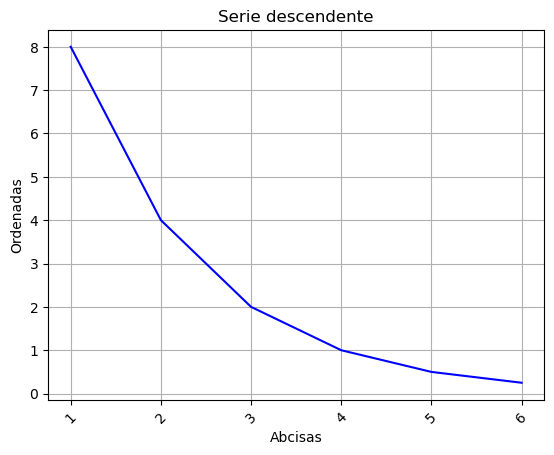

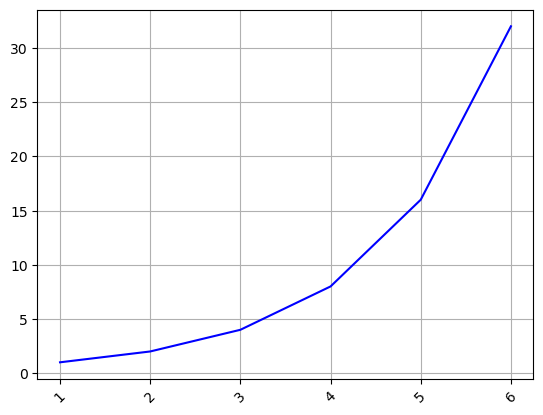

In [31]:
# Pruebas de funcionamiento:

representar_xxx_yyy([(1, 8), (2, 4), (3, 2), (4, 1), (5, 0.5), (6, 0.25)], ["Serie descendente", "Ordenadas", "Abcisas"])

representar_xxx_yyy([(1, 1), (2, 2), (3, 4), (4, 8), (5, 16), (6, 32)])

Salida esperada:

<img src='images/graph_01.png' width='800px' alt='Salida esperada del gráfico anterior: curva descentente y curva ascendente' />

### Una gráfica concreta

Deseamos representar el número de películas de nuestra base de datos que se han producido en un intervalo de años dado.

In [32]:
def repr_movies_years(movie_dict: dict, start_year: int, end_year: int) -> None:
    """
    Representa el número de películas producidas en un intervalo de años dado.

    Parameters
    ----------
    movie_dict
        Diccionario que contiene los datos de las películas, donde las claves son los títulos de las películas 
        y los valores son tuplas con información sobre las películas.
    start_year
        El año de inicio del intervalo.
    end_year
        El año final del intervalo.

    Returns
    -------
    None
        Esta función solo genera y muestra un gráfico, no devuelve valores.

    Example
    --------
    >>> repr_movies_years(main_dict_data, 2000, 2010)
    """

    movie_count_per_year = {}

    for movie_data in movie_dict.keys():
        try:
            year = int(movie_data[1])
            if start_year <= year <= end_year:
                if year not in movie_count_per_year:
                    movie_count_per_year[year] = 0
                movie_count_per_year[year] += 1
        except (ValueError, IndexError):
            continue

    pairs_list = [(year, count) for year, count in sorted(movie_count_per_year.items())]

    representar_xxx_yyy(pairs_list, ["Número de Películas", "Cantidad", "Año"])

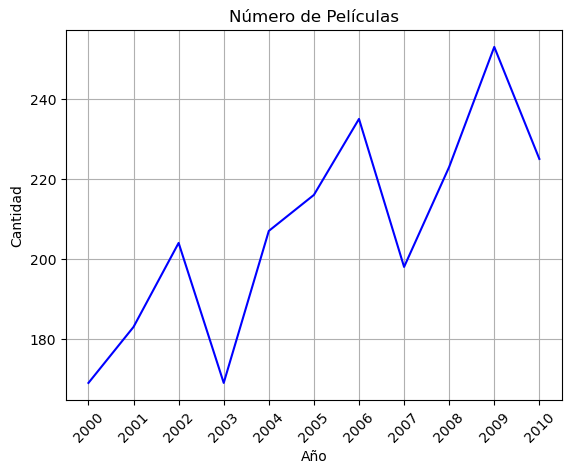

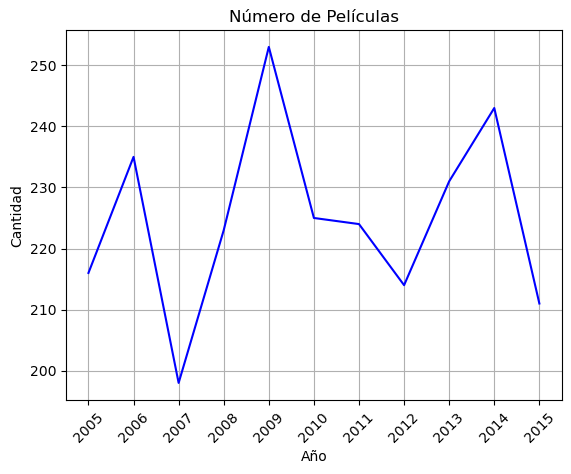

In [33]:
# Test de funcionamiento
repr_movies_years(main_dict_data, 2000, 2010)
repr_movies_years(main_dict_data, 2005, 2015)

Salida esperada:

<img src='images/graph_02.png' width='800px' alt='' />

# D. Acceso a las urls de imdb y webscraping [2 puntos]

### D.1. Recuperación de las URLs

Con sencillas instrucciones, deseamos recuperar todas las *urls* de las películas de nuestro archivo, mostrando cuántas son, la primera de ellas o las diez primeras por ejemplo:

In [34]:
urls = [fila[7] for fila in main_dict_data.values()]
first_url_movie = urls[0] if urls else None
first_ten_urls = urls[:10]

In [35]:
# Test de funcionamiento

print(len(urls))

print()

print(first_url_movie)

print()

print(first_ten_urls)

4919

http://www.imdb.com/title/tt0499549/

['http://www.imdb.com/title/tt0499549/', 'http://www.imdb.com/title/tt0449088/', 'http://www.imdb.com/title/tt2379713/', 'http://www.imdb.com/title/tt1345836/', 'http://www.imdb.com/title/tt5289954/', 'http://www.imdb.com/title/tt0401729/', 'http://www.imdb.com/title/tt0413300/', 'http://www.imdb.com/title/tt0398286/', 'http://www.imdb.com/title/tt2395427/', 'http://www.imdb.com/title/tt0417741/']


Salida esperada:

    4919
    
    http://www.imdb.com/title/tt0499549/
    
    ['http://www.imdb.com/title/tt0499549/', 'http://www.imdb.com/title/tt0449088/', 'http://www.imdb.com/title/tt2379713/', 'http://www.imdb.com/title/tt1345836/', 'http://www.imdb.com/title/tt5289954/', 'http://www.imdb.com/title/tt0401729/', 'http://www.imdb.com/title/tt0413300/', 'http://www.imdb.com/title/tt0398286/', 'http://www.imdb.com/title/tt2395427/', 'http://www.imdb.com/title/tt0417741/']    

### D.2. Carga de la estructura sintáctica de una URL

Ahora, deseamos extraer el código `html` de una película.

In [36]:
# Una forma de evitar el error "Requests 403 forbidden" al hacer web scraping en las siguientes celdas:

HEADERS = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:98.0) Gecko/20100101 Firefox/98.0",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.5",
        "Accept-Encoding": "gzip, deflate",
        "Connection": "keep-alive",
        "Upgrade-Insecure-Requests": "1",
        "Sec-Fetch-Dest": "document",
        "Sec-Fetch-Mode": "navigate",
        "Sec-Fetch-Site": "none",
        "Sec-Fetch-User": "?1",
        "Cache-Control": "max-age=0",
    }

In [37]:
def soup_movie(url: str) -> Optional[object]:
    """
    Crea un objeto BeautifulSoup a partir del contenido HTML obtenido de una URL.

    Parameters
    ----------
    url
        La URL de la página web que se desea analizar.

    Returns
    -------
    Optional[object]
        Un objeto BeautifulSoup con el contenido HTML
        o None en caso de error.

    Examples
    --------
    >>> soup = soup_movie("https://www.example.com")
    >>> if soup is not None:
    ...     print(soup.title)
    <title>Example Domain</title>
    """
    try:

        response = requests.get(url, headers=HEADERS)
        if response.status_code == 200:
            return BeautifulSoup(response.text, "html.parser")
        else:
            print(f"Error {response.status_code} in the request of {url}")
            return None

    except Exception as e:
        print(f"Request Error {url}: {e}")
        return None

In [38]:
# Test de funcionamiento

soup = soup_movie(first_url_movie)

print(str(soup)[:1000])
print()
print("... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ...")
print()
print(str(soup)[-1000:])

<!DOCTYPE html>
<html lang="en-US" xmlns:fb="http://www.facebook.com/2008/fbml" xmlns:og="http://opengraphprotocol.org/schema/"><head><meta charset="utf-8"/><meta content="width=device-width" name="viewport"/><script>if(typeof uet === 'function'){ uet('bb', 'LoadTitle', {wb: 1}); }</script><script>window.addEventListener('load', (event) => {
        if (typeof window.csa !== 'undefined' && typeof window.csa === 'function') {
            var csaLatencyPlugin = window.csa('Content', {
                element: {
                    slotId: 'LoadTitle',
                    type: 'service-call'
                }
            });
            csaLatencyPlugin('mark', 'clickToBodyBegin', 1743018816042);
        }
    })</script><title>Avatar (2009) - IMDb</title><meta content="Avatar: Directed by James Cameron. With Sam Worthington, Zoe Saldaña, Sigourney Weaver, Stephen Lang. A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following his orders and pr

Salida esperada:

    <!DOCTYPE html>
    <html lang="en-US" translate="no" xmlns:fb="http://www.facebook.com/2008/fbml" xmlns:og="http://opengraphprotocol.org/schema/"><head><meta charset="utf-8"/><meta content="width=device-width" name="viewport"/><script>if(typeof uet === 'function'){ uet('bb', 'LoadTitle', {wb: 1}); }</script><script>window.addEventListener('load', (event) => {
            if (typeof window.csa !== 'undefined' && typeof window.csa === 'function') {
                var csaLatencyPlugin = window.csa('Content', {
                    element: {
                        slotId: 'LoadTitle',
                        type: 'service-call'
                    }
                });
                csaLatencyPlugin('mark', 'clickToBodyBegin', 1738853581913);
            }
        })</script><title>Avatar (2009) - IMDb</title><meta content="Avatar: Directed by James Cameron. With Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen Lang. A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following hi
    
    ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ...
    
    g(e+c);return!!e}function n(){for(var e=RegExp("^https://(.*\.(images|ssl-images|media)-amazon\.com|"+c.location.hostname+")/images/","i"),d={},h=0,k=c.performance.getEntriesByType("resource"),l=!1,b,a,m,f=0;f<k.length;f++)if(a=k[f],0<a.transferSize&&a.transferSize>=a.encodedBodySize&&(b=e.exec(String(a.name)))&&3===b.length){a:{b=a.serverTiming||[];for(a=0;a<b.length;a++)if("provider"===b[a].name){b=b[a].description;break a}b=void 0}b&&(l||(l=g(b,"_cdn_fr")),
    a=d[b]=(d[b]||0)+1,a>h&&(m=b,h=a))}g(m,"_cdn_mp")}d.ue&&"function"===typeof d.ue.tag&&c.performance&&c.location&&n()},"cdnTagging")(ue_csm,window);
    
    
    }
    
    /* ◬ */
    </script>
    </div>
    <noscript>
    <img alt="" height="1" src="//fls-na.amazon.com/1/batch/1/OP/A1EVAM02EL8SFB:130-1575513-7998461:SMWGHB497V5D4NRH3FAY$uedata=s:%2Fuedata%2Fuedata%3Fnoscript%26id%3DSMWGHB497V5D4NRH3FAY:0" style="display:none;visibility:hidden;" width="1"/>
    </noscript>
    <script>window.ue && ue.count && ue.count('CSMLibrarySize', 61663)</script></div></body></html>

### D.3. Extracción de algunas piezas de información de una URL

Y ahora, con dicho código, deseamos extraer la siguiente información, referida a la película `first_url_movie`:

- La etiqueta completa del título de la película
- La descripción (sólo el contenido).
- La lista de actores
- La información sobre el presupuesto

In [39]:
def extract_content_from_soup(soup: object) -> Tuple[Optional[object], Optional[object], Optional[List[str]], Optional[str]]:
    """
    Extrae el título, la descripción y el reparto de una película de un objeto BeautifulSoup.

    Parameters
    ----------
    soup
        Un objeto BeautifulSoup que contiene la información de una página web.

    Returns
    -------
    Tuple
        Una tupla con:
        - El título de la película.
        - La descripción de la película.
        - Una lista con los nombres de los actores.
        - La información sobre el presupuesto de la película.

    Example
    --------
    >>> extract_content_from_soup(soup)
    (<title>Avatar (2009) - IMDb</title>, <meta content="A paraplegic Marine dispatched..." name="description"/>, ['Sam Worthington', 'Zoe Saldana', ...])
    """
    title = soup.find("title")
    description = soup.find("meta", attrs={"name": "description"})

    cast_tags = soup.find_all("a", class_="sc-cd7dc4b7-1 kVdWAO")
    actors = [actor.get_text().strip() for actor in cast_tags] if cast_tags else []

    budget_tag = soup.find("li", {"data-testid": "title-boxoffice-budget"})
    budget = None
    if budget_tag:
        budget_content = budget_tag.find("span", class_="ipc-metadata-list-item__list-content-item")
        if budget_content:
            budget = budget_content.get_text(strip=True)

    return title, description, actors, budget


title, description, actors, budget = extract_content_from_soup(soup)

print(title)
print(description['content'] if description else "No encontrada")
print(actors)
print(budget)


<title>Avatar (2009) - IMDb</title>
Avatar: Directed by James Cameron. With Sam Worthington, Zoe Saldaña, Sigourney Weaver, Stephen Lang. A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following his orders and protecting the world he feels is his home.
['Sam Worthington', 'Zoe Saldaña', 'Sigourney Weaver', 'Michelle Rodriguez', 'Stephen Lang', 'Giovanni Ribisi', 'Joel David Moore', 'CCH Pounder', 'Wes Studi', 'Laz Alonso', 'Dileep Rao', 'Matt Gerald', 'Sean Anthony Moran', 'Jason Whyte', 'Scott Lawrence', 'Kelly Kilgour', 'James Patrick Pitt', 'Sean Patrick Murphy']
$237,000,000 (estimated)


Salida esperada:

    <title>Avatar (2009) - IMDb</title>
    
    Avatar: Directed by James Cameron. With Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen Lang. A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following his orders and protecting the world he feels is his home.
    
    ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Michelle Rodriguez', 'Stephen Lang', 'Giovanni Ribisi', 'Joel David Moore', 'CCH Pounder', 'Wes Studi', 'Laz Alonso', 'Dileep Rao', 'Matt Gerald', 'Sean Anthony Moran', 'Jason Whyte', 'Scott Lawrence', 'Kelly Kilgour', 'James Patrick Pitt', 'Sean Patrick Murphy']
    
    $237,000,000 (estimated)

### D.4. Actores que intervienen en una lista de URLs

Necesitamos crear un archivo con los actores de las películas de IMDB, dada la lista de sus URLs.

In [40]:
def gather_actors(output_file: str, urls: List[str]) -> None:
    """
    Extrae los nombres de los actores de una lista de URLs y los almacena en un archivo.

    Parameters
    ----------
    output_file 
        La ruta del archivo donde se almacenarán los nombres de los actores.
    urls
        Una lista de URLs de películas.

    Returns
    -------
    None

    Example
    --------
    >>> gather_actors("actores.txt", ["http://www.imdb.com/title/tt0499549/", "http://www.imdb.com/title/tt0120338/"])
    """
    with open(output_file, "w", encoding="utf-8") as f:
        list_actors = set()

        for url in urls:
            soup = soup_movie(url)
            if soup:
                cast_div = soup.find_all('a', class_='sc-cd7dc4b7-1 kVdWAO')

                for actor in cast_div:
                    list_actors.add(actor.text.strip())

        for actor in list_actors:
            f.write(f"{actor}\n")


In [41]:
# Test de funcionamiento

# OJO: esta operación puede llevar bastante tiempo.
# Para esta prueba, usamos un número limitado de películas.

gather_actors("actors_3_first_movies.txt", urls[:3])

with open("actors_3_first_movies.txt") as f:
    for _ in range(10):
        line = f.readline().strip()
        print(line)

CCH Pounder
David Schofield
Mackenzie Crook
David Bailie
James Patrick Pitt
Stephanie Sigman
Martin Klebba
Lee Arenberg
Lauren Maher
Ben Whishaw


Salida esperada:

    Sam Worthington
    Zoe Saldana
    Sigourney Weaver
    Michelle Rodriguez
    Stephen Lang
    Giovanni Ribisi
    Joel David Moore
    CCH Pounder
    Wes Studi
    Laz Alonso

In [42]:
# La siguente llamada llevaría un tiempo realmente largo:

# import time # para cronometrar esta función, que tarda mucho

# reloj_inicio = time.time()
# gather_actors("actors_all_movies.txt", urls)
# reloj_fin = time.time()

# print("Tiempo invertido: %s segundos." % (reloj_fin - reloj_inicio))

# E. Pandas [2 puntos]

### E.1. El primer paso es la carga del archivo en un dataframe

In [43]:
def load_dataframe(file_path: str) -> pd.DataFrame:
    """
    Carga un archivo csv en un DataFrame utilizando.

    Parameters
    ----------
    file_path
        La ruta al archivo que contiene los datos.

    Returns
    -------
    pd.DataFrame
        Un DataFrame con los datos del archivo.

    Examples
    --------
    >>> tabla_completa = load_dataframe(MOVIES_DATA)
    >>> tabla_completa.head()
    """
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error loading file: {e}")
        return pd.DataFrame()




In [44]:
# Test de funcionamiento

tabla_completa = load_dataframe(MOVIES_DATA)

tabla_completa

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660


Salida esperada:

<img src='images/df_01.png' width='800px' alt='' />

### E.2. Tabla de los campos principales

A pertir de la tabla anterior, construimos otra con sólo algumos de los campos:

In [45]:
def fields_selected_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye un DataFrame con campos seleccionados a partir del DataFrame completo.

    Parameters
    ----------
    df
        DataFrame completo con todos los datos.

    Returns
    -------
    pd.DataFrame
        DataFrame que contiene únicamente las columnas:
        ['movie_title', 'color', 'director_name', 'language', 'country', 
         'actor_1_name', 'movie_imdb_link'].

    Examples
    --------
    >>> tabla_breve = fields_selected_dataframe(tabla_completa)
    >>> tabla_breve.head()
    """
    campos = ['movie_title', 'color', 'director_name', 'language', 'country', 
              'actor_1_name', 'movie_imdb_link']
    return df[campos]


In [46]:
# test de comprobación

tabla_breve = fields_selected_dataframe(tabla_completa)

tabla_breve

,movie_title,color,director_name,language,country,actor_1_name,movie_imdb_link
0,Avatar,Color,James Cameron,English,USA,CCH Pounder,http://www.imdb.com/title/tt0499549/?ref_=fn_t...
1,Pirates of the Caribbean: At World's End,Color,Gore Verbinski,English,USA,Johnny Depp,http://www.imdb.com/title/tt0449088/?ref_=fn_t...
2,Spectre,Color,Sam Mendes,English,UK,Christoph Waltz,http://www.imdb.com/title/tt2379713/?ref_=fn_t...
3,The Dark Knight Rises,Color,Christopher Nolan,English,USA,Tom Hardy,http://www.imdb.com/title/tt1345836/?ref_=fn_t...
4,Star Wars: Episode VII - The Force Awakens ...,NaN,Doug Walker,NaN,NaN,Doug Walker,http://www.imdb.com/title/tt5289954/?ref_=fn_t...
...,...,...,...,...,...,...,...
5038,Signed Sealed Delivered,Color,Scott Smith,English,Canada,Eric Mabius,http://www.imdb.com/title/tt3000844/?ref_=fn_t...
5039,The Following,Color,NaN,English,USA,Natalie Zea,http://www.imdb.com/title/tt2071645/?ref_=fn_t...
5040,A Plague So Pleasant,Color,Benjamin Roberds,English,USA,Eva Boehnke,http://www.imdb.com/title/tt2107644/?ref_=fn_t...
5041,Shanghai Calling,Color,Daniel Hsia,English,USA,Alan Ruck,http://www.imdb.com/title/tt2070597/?ref_=fn_t...


Salida esperada:

<img src='images/df_02.png' width='800px' alt='' />

### E.3. Columnas de una tabla

¿Cuáles son las columnas de nuestrsa `tabla_breve`?

In [47]:
print(tabla_breve.columns)

Index(['movie_title', 'color', 'director_name', 'language', 'country',
       'actor_1_name', 'movie_imdb_link'],
      dtype='object')


Salida esperada:

    Index(['movie_title', 'color', 'director_name', 'language', 'country',
           'actor_1_name', 'movie_imdb_link'],
          dtype='object')

### E.4. Campos missing

Algunos campos muestran un valod `NaN`. Deseamos cambiarlo por una cadena de caracteres: `"Desc"`.

In [48]:
tabla_breve = tabla_breve.fillna("Desc")


In [49]:
# Test de comprobación

tabla_breve

,movie_title,color,director_name,language,country,actor_1_name,movie_imdb_link
0,Avatar,Color,James Cameron,English,USA,CCH Pounder,http://www.imdb.com/title/tt0499549/?ref_=fn_t...
1,Pirates of the Caribbean: At World's End,Color,Gore Verbinski,English,USA,Johnny Depp,http://www.imdb.com/title/tt0449088/?ref_=fn_t...
2,Spectre,Color,Sam Mendes,English,UK,Christoph Waltz,http://www.imdb.com/title/tt2379713/?ref_=fn_t...
3,The Dark Knight Rises,Color,Christopher Nolan,English,USA,Tom Hardy,http://www.imdb.com/title/tt1345836/?ref_=fn_t...
4,Star Wars: Episode VII - The Force Awakens ...,Desc,Doug Walker,Desc,Desc,Doug Walker,http://www.imdb.com/title/tt5289954/?ref_=fn_t...
...,...,...,...,...,...,...,...
5038,Signed Sealed Delivered,Color,Scott Smith,English,Canada,Eric Mabius,http://www.imdb.com/title/tt3000844/?ref_=fn_t...
5039,The Following,Color,Desc,English,USA,Natalie Zea,http://www.imdb.com/title/tt2071645/?ref_=fn_t...
5040,A Plague So Pleasant,Color,Benjamin Roberds,English,USA,Eva Boehnke,http://www.imdb.com/title/tt2107644/?ref_=fn_t...
5041,Shanghai Calling,Color,Daniel Hsia,English,USA,Alan Ruck,http://www.imdb.com/title/tt2070597/?ref_=fn_t...


Salida esperada:

<img src='images/df_03.png' width='800px' alt='' />

### E.5. Director $\rightarrow$ películas y número de películas

Función que averigua la lista de títulos de películas de un director dado:

In [50]:
def titulos_de_director_df(df: pd.DataFrame, director: str) -> pd.DataFrame:
    """
    Devuelve un DataFrame con los títulos de las películas de un director dado.

    Parameters
    ----------
    df
        DataFrame que contiene la información de las películas.
    director
        Nombre del director cuyas películas se desean extraer.

    Returns
    -------
    pd.DataFrame
        DataFrame que contiene únicamente la columna 'movie_title' con los títulos de las películas
        dirigidas por el director especificado.

    Examples
    --------
    >>> tabla_tits = titulos_de_director_df(tabla_breve, "James Cameron")
    >>> tabla_tits
    """
    return df.loc[df["director_name"] == director, ["movie_title"]]



In [51]:
# Test de comprobación:

tabla_tits = titulos_de_director_df(tabla_breve, "James Cameron")
tabla_tits

,movie_title
0,Avatar
26,Titanic
288,Terminator 2: Judgment Day
291,True Lies
606,The Abyss
2486,Aliens
3575,The Terminator


Salida esperada:

<img src='images/df_04.png' width='800px' alt='' />

In [52]:
list_tits = tabla_tits["movie_title"].to_list()
print(list_tits)

['Avatar\xa0', 'Titanic\xa0', 'Terminator 2: Judgment Day\xa0', 'True Lies\xa0', 'The Abyss\xa0', 'Aliens\xa0', 'The Terminator\xa0']


Salida esperada:

    ['Avatar\xa0', 'Titanic\xa0', 'Terminator 2: Judgment Day\xa0', 'True Lies\xa0', 'The Abyss\xa0', 'Aliens\xa0', 'The Terminator\xa0']

¿Qué directores han dirigido más de *n* películas?

In [53]:
def directors_max_movies_df(df: pd.DataFrame) -> tuple:
    """
    Devuelve una tupla que contiene una lista de directores que han dirigido el máximo número de películas
    y el número de películas.

    Parameters
    ----------
    df
        DataFrame que contiene los datos de las películas.
            
    Returns
    -------
    tuple
        Una tupla en la forma ([director1, director2, ...], np.int64(num_peliculas))
        
    Examples
    --------
    >>> result = directors_max_movies_df(short_table)
    >>> result
    (['Steven Spielberg'], np.int64(26))
    """

    filtered_df = df[df["director_name"] != "Desc"]
    
    director_counts = filtered_df["director_name"].value_counts()
    max_count = director_counts.max()
    
    max_directors = director_counts[director_counts == max_count].index.tolist()
    
    return (max_directors, max_count)

In [54]:
# test de comprobación:

directors_max_movies_df(tabla_breve)

(['Steven Spielberg'], 26)

Salida esperada:

    (['Steven Spielberg'], np.int64(26))

# Parte F. Un cálculo masivo con map-reduce [0,5 puntos]

En este apartado se ha de realizar un programa aparte, *basado en la técnica de map-reduce*, que calcule, para cada idioma, en qué países en que se han producido películas y la suma de los presupuestos de dichas películas. Cuando el idioma o el país o el presupuesto no se conozcan, no se considerará esta película.

    C:\...> python language_budget_countries.py -q algunos_campos.txt

El programa funcionará necesariamente con la técnica map-reduce, que podemos poner en juego con la librería `mrjob`.

El funcionamiento del mismo se puede activar también desde aquí:

In [55]:
# Hagamos una llamada al programa de consola desde aquí:

! python -c "import mrjob; print(mrjob.__version__)"

! python language_budget_countries.py -q algunos_campos.txt

0.7.4
"Aboriginal"	["UK",80000000.0]
"Aboriginal"	["Australia",6000000.0]
"Arabic"	["Turkey",8300000.0]
"Arabic"	["Egypt",1500000.0]
"Arabic"	["France",1300000.0]
"Arabic"	["United Arab Emirates",125000.0]
"Aramaic"	["USA",30000000.0]
"Bosnian"	["USA",13000000.0]
"Cantonese"	["Hong Kong",129500000.0]
"Cantonese"	["China",25000000.0]
"Chinese"	["China",12000000.0]
"Czech"	["Czech Republic",84450000.0]
"Danish"	["Denmark",50100000.0]
"Dari"	["USA",20000000.0]
"Dari"	["Afghanistan",46000.0]
"Dutch"	["Netherlands",32150000.0]
"Dzongkha"	["Australia",1800000.0]
"English"	["USA",119992626596.0]
"English"	["UK",9550739127.0]
"English"	["New Zealand",645850000.0]
"English"	["Canada",1551512000.0]
"English"	["Australia",1415805523.0]
"English"	["Germany",2841610000.0]
"English"	["China",287005000.0]
"English"	["New Line",90000000.0]
"English"	["France",2960460000.0]
"English"	["Japan",229000000.0]
"English"	["Spain",364450000.0]
"English"	["Hong Kong",150000000.0]
"English"	["Czech Republic",62

In [56]:
# Para que el resultado se almacene en un archivo:

! python language_budget_countries.py -q algunos_campos.txt > language_countries_budgets.txt

Para que pueda yo ver tu programa cómodamente desde aquí, también se puede mostrar con un comando de la consola, anteponiendo el símbolo `!`. Observaciones:

- La instrucción siguiente está comentada para ocultar una solución mía.
  Tú debes suprimir el símbolo `#` del comentario
  para mostrar tu solución aquí.
- Desde mac o linux, se ha de usar el comando `cat`, en vez de `type`.

In [57]:
! type language_budget_countries.py

import sys
from mrjob.job import MRJob

class MRLanguageBudgetCountries(MRJob):
    """
    MapReduce job que calcula el presupuesto total por país para cada idioma en los datos de películas.

    Cada línea del archivo de entrada debe tener el siguiente formato:
        "título|año|idioma|país|presupuesto"
    
    Se ignoran líneas que no cumplan con el formato o que tengan datos no válidos.
    """
    def mapper(self, _, linea):
        """
        Procesa una línea de entrada y emite tuplas (idioma, (país, presupuesto)).

        Parameters
        ----------
        _ : any
            Clave no utilizada.
        linea : str
            Línea de texto que contiene los datos de una película en el formato:
            "título|año|idioma|país|presupuesto".
        
        Yields
        ------
        tuple
            Clave-valor de la forma (idioma, (país, presupuesto)).

        Examples
        --------
        >>> list(MRLanguageBudgetCountries().mapper(None, "Pelicula|2020|Es

# Parte G. Un apartado libre [0.5 puntos]

<font color="darkblue">
Se me ha quedado corto con el uso básico de pandas, por lo que he ampliado su aplicación para limpiar y transformar los datos de películas de forma más completa. Además, he integrado Plotly para generar gráficos interactivos (como histogramas de puntuaciones IMDb y gráficos de barras por año), lo que aporta un acabado visual más profesional. Por último, he incorporado una interfaz de usuario con Tkinter para hacer la aplicación más amigable, permitiendo seleccionar una película y ver sus detalles actualizados dinámicamente, en línea con lo que se pide en el enunciado.
</font>

In [58]:
def process_data(file_path: str) -> pd.DataFrame:
    """
    Procesa los datos de películas desde un archivo CSV y devuelve un DataFrame.

    Parameters
    ----------
    file_path
        Ruta del archivo CSV con los datos de las películas.

    Returns
    -------
    pd.DataFrame
        DataFrame con los datos procesados de las películas.

    Examples
    --------
    >>> df = process_data("movies.csv")
    >>> print(df.head())
    """
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error loading file: {e}")
    
    df = df.drop_duplicates(subset='movie_title')
    df = df.dropna(subset=['title_year'])
    df['title_year'] = pd.to_numeric(df['title_year'], errors='coerce').fillna(0).astype(int)
    return df

def plot_imdb_histogram(df: pd.DataFrame):
    """
    Genera un histograma interactivo de las puntuaciones de IMDb.

    Parameters
    ----------
    df
        DataFrame con los datos de las películas.
    
    Returns
    -------
    None
        No devuelve ningún valor, solo muestra el gráfico.

    Examples
    --------
    >>> df = process_data("movies.csv")
    >>> plot_imdb_histogram(df)
    """
    if 'imdb_score' in df.columns:
        fig = px.histogram(df, x='imdb_score', nbins=20, labels={'imdb_score': 'Puntuación IMDb'},
                            title='Distribución de Puntuaciones IMDb', opacity=0.75)
        fig.show()

def plot_movies_per_year(df: pd.DataFrame):
    """
    Genera un gráfico de barras mostrando la cantidad de películas por año.

    Parameters
    ----------
    df
        DataFrame con los datos de las películas.
    
    Returns
    -------
    None
        No devuelve ningún valor, solo muestra el gráfico.

    Examples
    --------
    >>> df = process_data("movies.csv")
    >>> plot_movies_per_year(df)
    """
    if 'title_year' in df.columns:
        movies_per_year = df.groupby('title_year').size().reset_index(name='movie_count')
        fig = px.bar(movies_per_year, x='title_year', y='movie_count', labels={'title_year': 'Año', 'movie_count': 'Cantidad de Películas'},
                     title='Número de Películas por Año')
        fig.show()

def display_movie_details(df: pd.DataFrame, selected_movie_title: str):
    """
    Muestra los detalles de una película seleccionada.

    Parameters
    ----------
    df
        DataFrame con los datos de las películas.
    selected_movie_title : str
        Título de la película seleccionada.
    
    Returns
    -------
    None
        No devuelve ningún valor, solo imprime los detalles de la película.

    Examples
    --------
    >>> df = process_data("movies.csv")
    >>> display_movie_details(df, "Inception")
    """
    movie = df[df['movie_title'] == selected_movie_title]
    if movie.empty:
        print(f"No se encontró la película '{selected_movie_title}'.")
        return
    movie_details = movie.iloc[0]
    print(f"\nDetalles de la película '{selected_movie_title}':")
    print(f"Título: {movie_details['movie_title']}")
    print(f"Director: {movie_details.get('director_name', 'Desconocido')}")
    print(f"Idioma: {movie_details.get('language', 'Desconocido')}")
    print(f"País: {movie_details.get('country', 'Desconocido')}")
    print(f"Presupuesto: {movie_details.get('budget', 'Desconocido')}")
    print(f"Calificación IMDb: {movie_details.get('imdb_score', 'N/A')}")
    print(f"Enlace IMDb: {movie_details.get('movie_imdb_link', 'No disponible')}")

def create_ui(df: pd.DataFrame):
    """
    Crea la interfaz de usuario para interactuar con los datos de las películas.

    Parameters
    ----------
    df
        DataFrame con los datos de las películas.
    
    Returns
    -------
    None
        No devuelve ningún valor, solo muestra la interfaz de usuario.

    Examples
    --------
    >>> df = process_data("movies.csv")
    >>> create_ui(df)
    """
    root = tk.Tk()
    root.title("Movie Data Analysis")
    tk.Label(root, text="Movie Data Interactive Viewer", font=("Helvetica", 16)).grid(row=0, column=0, columnspan=2, pady=10)
    tk.Label(root, text="Selecciona una película:").grid(row=1, column=0, padx=10, pady=5, sticky='e')
    
    movies = sorted(df['movie_title'].dropna().unique())
    movie_combobox = ttk.Combobox(root, values=movies, state="readonly")
    movie_combobox.grid(row=1, column=1, padx=10, pady=5)
    
    def update_graphs_and_details():
        selected_movie = movie_combobox.get()
        if selected_movie:
            display_movie_details(df, selected_movie)
            plot_imdb_histogram(df[df['movie_title'] == selected_movie])
            plot_movies_per_year(df[df['movie_title'] == selected_movie])
    
    tk.Button(root, text="Mostrar Datos", command=update_graphs_and_details).grid(row=2, column=0, columnspan=2, pady=10)
    root.mainloop()


In [59]:

df = process_data(MOVIES_DATA)
if not df.empty:
    create_ui(df)



Detalles de la película '10 Things I Hate About You ':
Título: 10 Things I Hate About You 
Director: Gil Junger
Idioma: English
País: USA
Presupuesto: 16000000.0
Calificación IMDb: 7.2
Enlace IMDb: http://www.imdb.com/title/tt0147800/?ref_=fn_tt_tt_1


# Datos personales

<br>

<font color="darkblue">

-   **Apellidos:** Carrera Pintor
-   **Nombre:** David
-   **Email:** davidcarrera199@gmail.com
-   **Fecha:** 26/03/2025

<br>

<font color="black">
    
### Ficha de autoevaluación

<br>

<br>

<font color="darkblue">
    
|Apartado|Calificación|Comentario|
|-|-|-|
|a)  |2.0  / 2.0  |Completamente resuelto |
|b)  |2.0  / 2.0  |Completamente resuelto |
|c)  |1.0  / 1.0  |Completamente resuelto |
|d)  |2.0  / 2.0  |Completamente resuelto |
|e)  |2.0  / 2.0  |Completamente resuelto |
|f)  |0.5  / 0.5  |Completamente resuelto |
|g)  |0.4  / 0.5  |Completamente resuelto |
|**Total** |**9.9** / 10.0|**Aprobado**|
</font>

<br>

<font color="black">
   
### Ayuda recibida y fuentes utilizadas
    
</font>

<br>
General:

    https://www.python.org/
    https://stackoverflow.com/
    Apuntes del profesor

Tkinter: https://docs.python.org/3/library/tkinter.html

Plotly: https://plotly.com/python/

</font>

<br>

In [60]:
# Esta celda se ha de respetar: está aquí para comprobar el funcionamiento de algunas funciones por parte de tu profesor

import sys
modulenames = set(sys.modules) & set(globals())

if "mrjob" in modulenames:
    print("* En las librerías importadas, la siguiente no es necesaria\n" +
          "      from mrjob.job import MRJob\n" +
          "  porque no va a usarse en el cuaderno, sino en un programa externo. Debe omitirse aquí.\n")

from os.path import exists

if not exists("./images/"):
    print("* He echado de menos la carpeta 'images'.\n")

# ----------------------------------------------------------------------------

if not 'defaultdict' in set(globals()) and not 'collections' in modulenames:
    print("El uso de diccionarios por defecto es muy importante y te recomiendo que te familiarices con ellos.")

# ----------------------------------------------------------------------------

nombres = dir()

# Constantes: .....................

# print("----------------- Constantes")

const_names_asked = ["MOVIES_DATA", "FEW_FIELDS"]
for const_name in const_names_asked:
    if const_name not in nombres:
        print("La constante '" + const_name + "' no se ha definido.\n")

# Funciones: .....................

# print("----------------- Funciones")

name_funcs_asked = ["load_full_data", "main_data_from_item", "datatypes_arranged", "load_main_data",
                    "movies_anno_for_director", "directors_max_movies", "years_num_movies", "store_file",
                    "actor_directors", "print_collaborations_min", "representar_xxx_yyy", "gather_actors",
                    "load_dataframe", "titulos_de_director_df", "directors_max_movies_df"]

name_funcs_defined = [f for f in name_funcs_asked if f in nombres]

name_funcs_not_defined = [f for f in name_funcs_asked if f not in nombres]

def comentario(frase, nombres) -> str:
    if nombres != []:
        print(frase + ": " + ", ".join(nombres) + ".\n")

comentario("Las funciones siguientes no están definidas: ", name_funcs_not_defined)

# Variables: .....................

# print("----------------- Variables")

name_vars_asked = ["full_header", "list_of_enumerated_headers", "datos_avatar_2009", "datos_star_wars_7",
                   "colores", "pelis_victor", "main_header", "main_dict_data", "num_movies", "num_movies_sorted",
                   "num_collaborations", "first_url_movie", "first_ten_urls", "response", "soup", "actors",
                   "presupuesto_apartado", "presupuesto_importe", "importe_str",
                   "tabla_breve", "tabla_tits", "list_tits"]

name_vars_not_defined = [v for v in name_vars_asked if v not in nombres]

comentario("Las variables siguientes no están calculadas: ", name_vars_not_defined)
              
# ----------------------------------------------------------------------------

# Funciones definidas: .....................

# print("----------------- Funciones definidas. Semántica")

funcs_defined = [globals()[f_name] for f_name in name_funcs_defined]

# print(funcs_defined)

# print("..............................................................................")

no_docstrings = [f.__name__ for f in funcs_defined if f.__doc__ is None]
comentario("Las funciones siguientes no tienen el docstring estándar: " , no_docstrings)

# print("..............................................................................")

escasos_docstrings = [f.__name__ for f in funcs_defined if f.__doc__ is not None and len(f.__doc__.split("\n")) < 2]
comentario("El docstring de las funciones siguientes es insuficiente: ", escasos_docstrings)

# print("----------------- Funcs. open sin contexto")

import inspect

fs_open_close = [f for f in name_funcs_defined
                 if "= open" in inspect.getsource(globals()[f])
                 or "=open" in inspect.getsource(globals()[f])]

comentario("* El manejo de archivos es mejor con un contexto 'with ...' en lugar de con open-close. " +
           "V. funciones siguientes", fs_open_close)

# print("----------------- Funcs. with readlines()")

fs_with_readlines = [f for f in funcs_defined if "readlines" in inspect.getsource(f)]

comentario("* La instrucción 'readlines()' carga un archivo entero en la memoria principal. " +
           "Esto conlleva un gasto de memoria realmente grande, " +
           "innecesario cuando sólo interesa una línea, o cuando puede procesarse " +
           "línea a línea. " +
           "Las siguientes funciones contienen la instrucción 'readlines'", fs_with_readlines)

# ----------------------------------------------------------------------------

if not exists("./language_budget_countries.py"):
    print("* El programa de map-reduce no está hecho. Te recomiendo " +
          "fuertemente que inviertas algún tiempo en él, pues los conceptos " +
          "que trata son importantes en el mundo de la ciencia de datos.")

Las variables siguientes no están calculadas: : response, presupuesto_apartado, presupuesto_importe, importe_str.

